# Does a degree pay off in European Union?

This notebook explores the relationship between tertiary education, overqualification rates, labour costs and youth unemployment across EU27 countries.

**Pipeline:**
1. Fetch 4 datasets from Eurostat API
2. Store in SQLite
3. K-Means clustering to segment countries by labour market profile
4. Visualise results

In [1]:
import sqlite3
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os.path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [2]:
DB_PATH = "data/labour_market.db"

EU27 = [
    "AT","BE","BG","CY","CZ","DE","DK","EE","EL","ES",
    "FI","FR","HR","HU","IE","IT","LT","LU","LV","MT",
    "NL","PL","PT","RO","SE","SI","SK"
]

YEARS = list(range(2010, 2024))

BASE_URL = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

## 1. Eurostat API

Eurostat returns data in JSON-stat 2.0 — values are stored as a flat dict/list indexed by a single integer that encodes all dimensions. The parser below reconstructs full coordinates from that flat index.

In [3]:
def fetch_eurostat(dataset: str, params: dict) -> pd.DataFrame:
    url = f"{BASE_URL}/{dataset}"
    params["format"] = "JSON"
    params["lang"] = "EN"

    print(f"Downloading: {dataset}...")
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    dims = data["id"]
    sizes = data["size"]

    # some dimensions with size=1 don't have 'index' key — handle both cases
    dim_labels = {}
    for d in dims:
        category = data["dimension"][d]["category"]
        if "index" in category:
            idx = category["index"]
            if isinstance(idx, list):
                dim_labels[d] = idx
            elif isinstance(idx, dict):
                dim_labels[d] = sorted(idx.keys(), key=lambda k: idx[k])
            else:
                dim_labels[d] = list(idx)
        else:
            dim_labels[d] = list(category["label"].keys())

    values = data["value"]
    rows = []

    if isinstance(values, dict):
        iterator = ((int(k), v) for k, v in values.items())
    elif isinstance(values, list):
        iterator = enumerate(values)
    else:
        iterator = []

    for flat_idx, val in iterator:
        if val is None:
            continue
        coords = {}
        remainder = flat_idx
        for dim, size in zip(reversed(dims), reversed(sizes)):
            coords[dim] = dim_labels[dim][remainder % size]
            remainder //= size
        coords["value"] = val
        rows.append(coords)

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No data returned for '{dataset}'. Check your query params.")

    return df

## 2. Download datasets

In [4]:
def fetch_overqualification() -> pd.DataFrame:
    params = {"sex": "T", "age": "Y25-64", "citizen": "TOTAL"}
    df = fetch_eurostat("lfsa_eoqgan", params)
    df = df[df["geo"].isin(EU27)]
    df = df[df["time"].astype(int).isin(YEARS)]
    df = df.rename(columns={"value": "overqualification_rate", "time": "year"})
    df["year"] = df["year"].astype(int)
    return df[["geo", "year", "overqualification_rate"]]


def fetch_labour_cost() -> pd.DataFrame:
    params = {"unit": "EUR", "lcstruct": "D1_D4_MD5", "nace_r2": "B-S_X_O"}
    df = fetch_eurostat("lc_lci_lev", params)
    df = df[df["geo"].isin(EU27)]
    df = df[df["time"].astype(int).isin(YEARS)]
    df = df.rename(columns={"value": "labour_cost_eur_h", "time": "year"})
    df["year"] = df["year"].astype(int)
    return df[["geo", "year", "labour_cost_eur_h"]]


def fetch_youth_unemployment() -> pd.DataFrame:
    params = {"sex": "T", "age": "Y15-29", "unit": "PC", "c_birth": "TOTAL"}
    df = fetch_eurostat("yth_empl_020", params)
    df = df[df["geo"].isin(EU27)]
    df = df[df["time"].astype(int).isin(YEARS)]
    df = df.rename(columns={"value": "youth_unemployment_rate", "time": "year"})
    df["year"] = df["year"].astype(int)
    return df[["geo", "year", "youth_unemployment_rate"]]


def fetch_tertiary_education() -> pd.DataFrame:
    params = {"sex": "T", "age": "Y25-64", "unit": "PC", "isced11": "ED5-8"}
    df = fetch_eurostat("edat_lfse_03", params)
    df = df[df["geo"].isin(EU27)]
    df = df[df["time"].astype(int).isin(YEARS)]
    df = df.rename(columns={"value": "tertiary_edu_rate", "time": "year"})
    df["year"] = df["year"].astype(int)
    return df[["geo", "year", "tertiary_edu_rate"]]

In [5]:
# skip download if db already exists
if not os.path.isfile(DB_PATH):
    os.makedirs("data", exist_ok=True)

    fetchers = {
        "overqualification": fetch_overqualification,
        "labour_cost": fetch_labour_cost,
        "youth_unemployment": fetch_youth_unemployment,
        "tertiary_education": fetch_tertiary_education,
    }

    datasets = {}
    for name, fn in fetchers.items():
        try:
            datasets[name] = fn()
            time.sleep(1)
        except Exception as e:
            print(f"Error in {name}: {e}")

    print(f"\nDownloaded {len(datasets)}/4 datasets")
else:
    print("DB already exists, skipping download")

DB already exists, skipping download


## 3. Save to SQLite

In [6]:
if not os.path.isfile(DB_PATH):
    conn = sqlite3.connect(DB_PATH)

    for table_name, df in datasets.items():
        df_clean = df.drop_duplicates(subset=["geo", "year"])
        df_clean.to_sql(table_name, conn, if_exists="replace", index=False)
        print(f"'{table_name}' — {len(df_clean)} rows")

    conn.execute("DROP VIEW IF EXISTS v_clustering_base")
    conn.execute("""
        CREATE VIEW v_clustering_base AS
        SELECT
            o.geo, o.year,
            o.overqualification_rate,
            lc.labour_cost_eur_h,
            yu.youth_unemployment_rate,
            te.tertiary_edu_rate
        FROM overqualification o
        LEFT JOIN labour_cost lc ON o.geo = lc.geo AND o.year = lc.year
        LEFT JOIN youth_unemployment yu ON o.geo = yu.geo AND o.year = yu.year
        LEFT JOIN tertiary_education te ON o.geo = te.geo AND o.year = te.year
        WHERE o.overqualification_rate IS NOT NULL
    """)
    conn.commit()
    conn.close()
    print(f"\nSaved to {DB_PATH}")

## 4. Exploratory analysis

Before clustering, let's look at the distributions and correlations.

In [7]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM v_clustering_base WHERE year = 2022", conn)
conn.close()

df.describe().round(1)

,year,overqualification_rate,labour_cost_eur_h,youth_unemployment_rate,tertiary_edu_rate
count,27.0,27.0,27.0,27.0,27.0
mean,2022.0,19.9,25.3,50.4,37.3
std,0.0,6.5,13.5,11.0,9.2
min,2022.0,6.3,8.2,33.1,19.7
25%,2022.0,14.8,13.9,44.0,29.7
50%,2022.0,19.2,18.8,48.4,39.5
75%,2022.0,22.2,39.0,57.2,43.7
max,2022.0,35.7,50.9,79.3,53.7


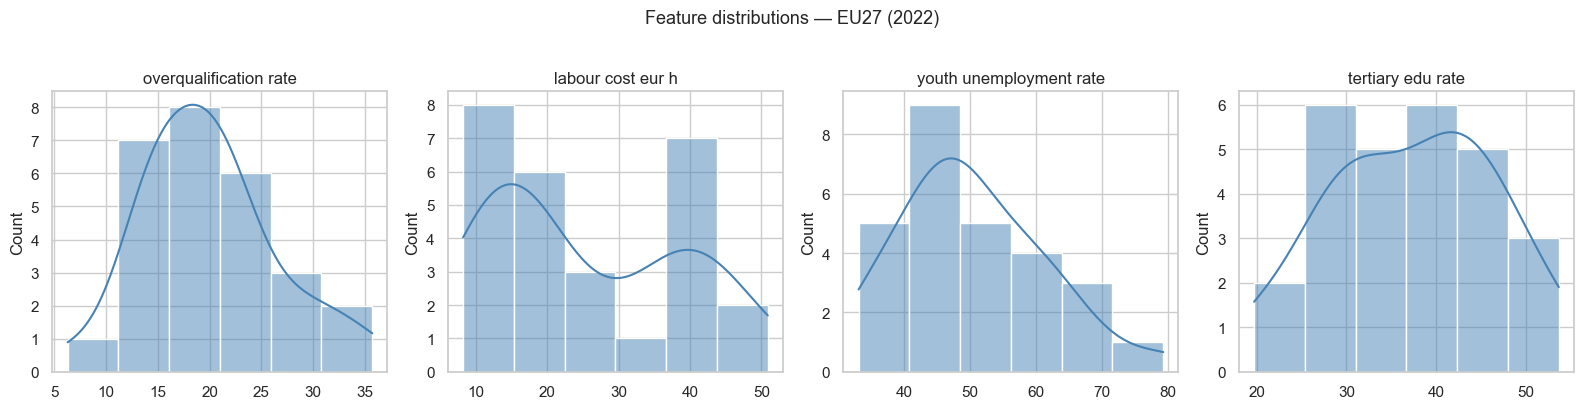

In [8]:
features = ["overqualification_rate", "labour_cost_eur_h", "youth_unemployment_rate", "tertiary_edu_rate"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, features):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("")

plt.suptitle("Feature distributions — EU27 (2022)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

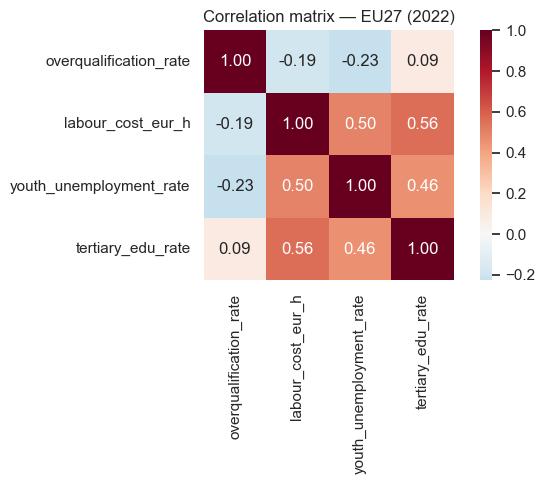

In [9]:
# correlation matrix — do richer countries have lower overqualification?
corr = df[features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix — EU27 (2022)")
plt.tight_layout()
plt.show()

## 5. Choosing k — elbow method

Running k-means for k=2 to k=8 and plot inertia. The elbow point tells us the optimal number of clusters.

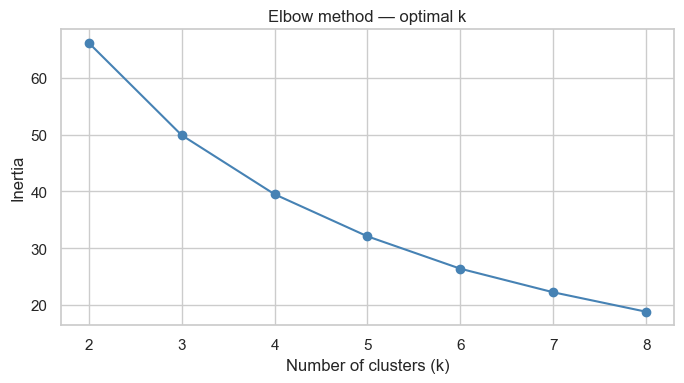

In [10]:
X = df[features].values
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method — optimal k")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 6. K-Means clustering (k=3)

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

# cluster centers in original scale
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
print("Cluster centers:")
centers.round(1)

Cluster centers:


,overqualification_rate,labour_cost_eur_h,youth_unemployment_rate,tertiary_edu_rate
0,17.7,14.5,42.2,27.2
1,18.2,39.3,59.4,42.8
2,25.5,17.4,46.6,41.7


In [12]:
# save clusters back to sqlite
conn = sqlite3.connect(DB_PATH)
df[["geo", "year", "cluster_id"]].to_sql("clusters", conn, if_exists="replace", index=False)
conn.close()
print("clusters table saved")

clusters table saved


## 7. Visualise clusters

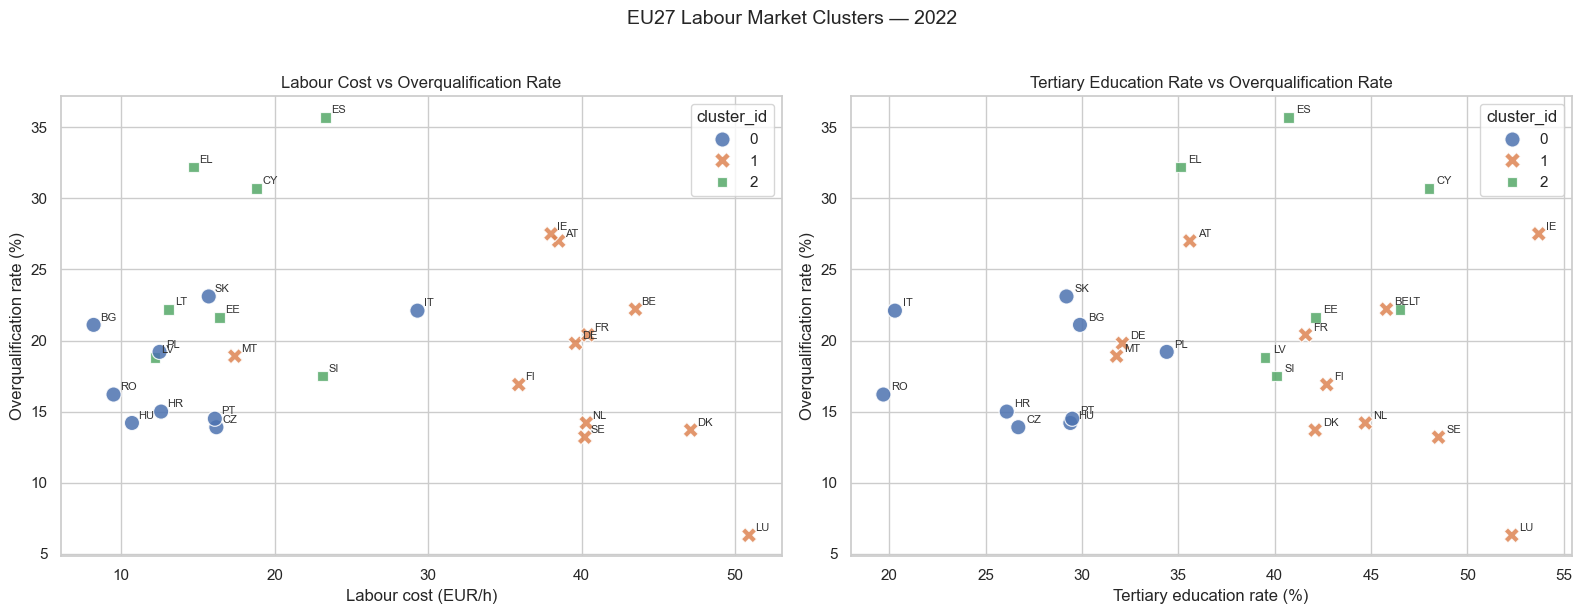

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# scatter: labour cost vs overqualification
sns.scatterplot(
    data=df, x="labour_cost_eur_h", y="overqualification_rate",
    hue="cluster_id", style="cluster_id", palette="deep", s=120, alpha=0.85, ax=axes[0]
)
for _, row in df.iterrows():
    axes[0].text(row["labour_cost_eur_h"] + 0.4, row["overqualification_rate"] + 0.3,
                 row["geo"], fontsize=8, color="#333")
axes[0].set_title("Labour Cost vs Overqualification Rate")
axes[0].set_xlabel("Labour cost (EUR/h)")
axes[0].set_ylabel("Overqualification rate (%)")

# scatter: tertiary education vs overqualification
sns.scatterplot(
    data=df, x="tertiary_edu_rate", y="overqualification_rate",
    hue="cluster_id", style="cluster_id", palette="deep", s=120, alpha=0.85, ax=axes[1]
)
for _, row in df.iterrows():
    axes[1].text(row["tertiary_edu_rate"] + 0.4, row["overqualification_rate"] + 0.3,
                 row["geo"], fontsize=8, color="#333")
axes[1].set_title("Tertiary Education Rate vs Overqualification Rate")
axes[1].set_xlabel("Tertiary education rate (%)")
axes[1].set_ylabel("Overqualification rate (%)")

plt.suptitle("EU27 Labour Market Clusters — 2022", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("data/clustering_2022.png", dpi=150, bbox_inches="tight")
plt.show()

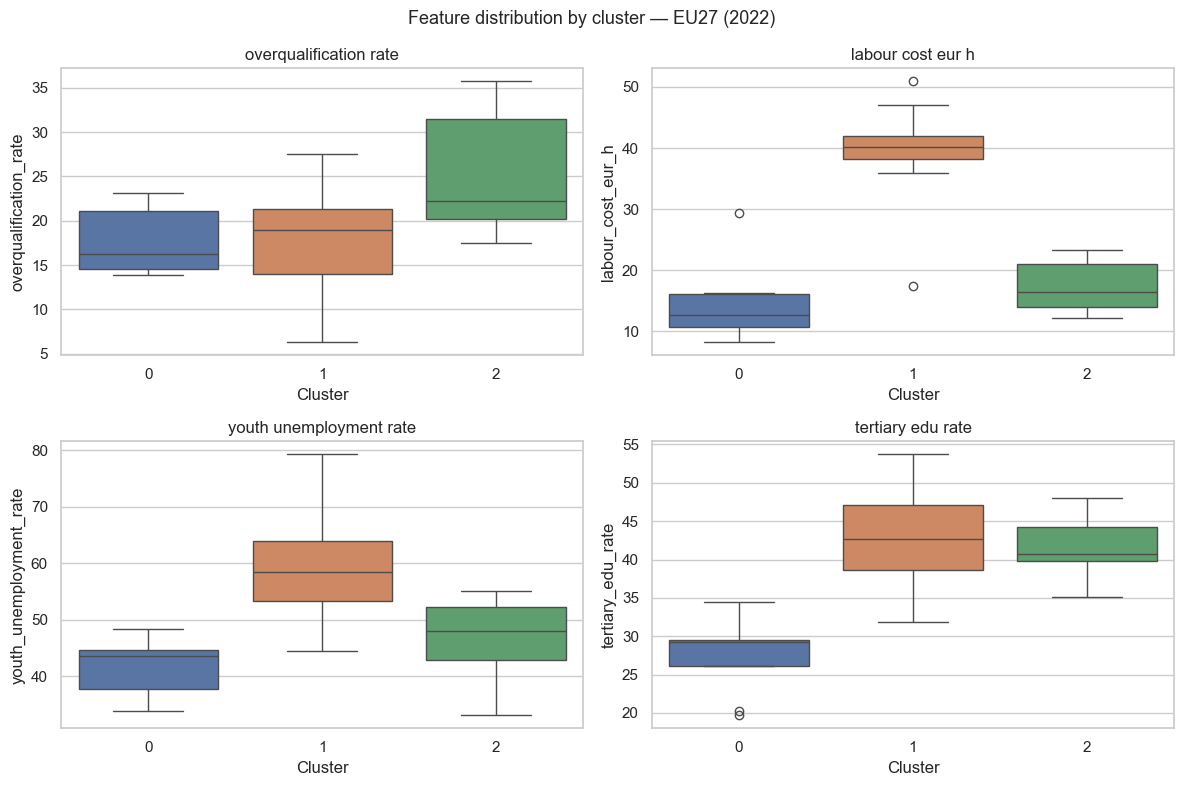

In [16]:
# boxplots — distribution of each feature per cluster
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="cluster_id", y=col, hue="cluster_id", palette="deep", legend=False, ax=ax)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Cluster")

plt.suptitle("Feature distribution by cluster — EU27 (2022)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Trend analysis — selected countries

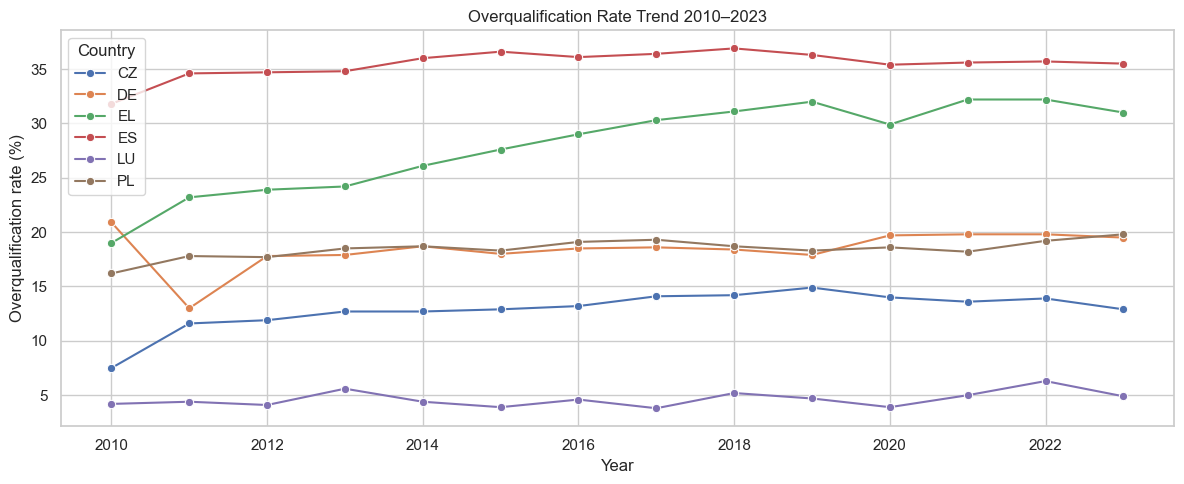

In [17]:
conn = sqlite3.connect(DB_PATH)
df_trend = pd.read_sql("SELECT * FROM v_clustering_base", conn)
conn.close()

countries = ["ES", "EL", "PL", "CZ", "DE", "LU"]
df_trend = df_trend[df_trend["geo"].isin(countries)]

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_trend, x="year", y="overqualification_rate", hue="geo", marker="o")
plt.title("Overqualification Rate Trend 2010–2023")
plt.xlabel("Year")
plt.ylabel("Overqualification rate (%)")
plt.legend(title="Country")
plt.tight_layout()
plt.show()